In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.optimize as so
import scipy.signal as ss
import matplotlib.patches as patches
import matplotlib.lines as mlines
try:
    import pySIMsalabim as sim
except ImportError: # add parent directory to sys.path if pySIMsalabim is not installed
    sys.path.append('../../../..')
    import pySIMsalabim as sim
from pySIMsalabim.experiments import impls
from pySIMsalabim.aux_funcs import time_domain_DRT as drt

In [2]:
# Read in the tj.dat file for both the capacitive and inductive devices
data_cap = pd.read_csv("Data/Default IS/tj.dat", sep=r'\s+')
data_ind = pd.read_csv("Data/Inductive IS/tj.dat", sep=r'\s+')

## Testing the $\mu$ criterion on an IS with 3 capacitive features

Following on from the work of Schonleber et al. (http://dx.doi.org/10.1016/j.electacta.2014.01.034), we can look at using their method for determining the best number of lifetimes per decade to use in a linear DRT fit. They define $\mu$ as 

$$\mu = 1 - \frac{\sum_{U_i < 0}|U_{i}|}{\sum_{U_i \geq 0}|U_{i}|}$$

Their fit method incrementally increases the number of lifetimes per decade by one until some threshold, $c$, is reached such that $\mu < c$. In their paper, they use $c = 0.85$.

[]

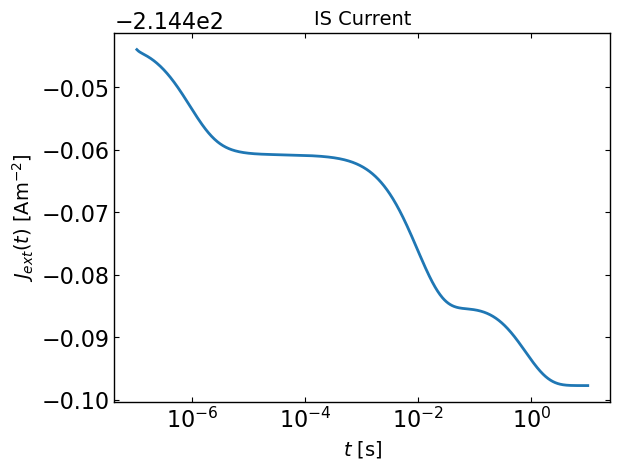

In [3]:
# Reduce the window of current and time to be used for fitting
start_index = 57
end_index = -1

time = data_cap['t'].iloc[start_index:end_index].values
current_density = (data_cap['Jext'].iloc[start_index:end_index].values)
current_density_numerical_error = data_cap['errJ'].iloc[start_index:end_index].values

plt.plot(time, current_density)
plt.xscale('log')
plt.xlabel('$t$ [$\\text{s}$]')
plt.ylabel('$J_{ext}(t)$ [$\\text{A} \\text{m}^{-2}$]')
plt.title("IS Current")
plt.plot()

In [4]:
# Scale current and error 
current_scaled = (current_density - current_density.min())/(current_density.max()-current_density.min())

In [5]:
m_dec_values = range(1,10)
mu_values = []
fits = []
no_decades = np.log10(time[-1]/time[0])
print(no_decades)

# Use linear fit for m_dec = [1, 10], checking [mu] as we go 
for m_dec in m_dec_values:
    # Generate m_dec lifetimes per decade 
    tau = np.geomspace(time[0], time[-1], int(m_dec*no_decades))

    # Fit the curve using linear fit
    fit = drt.fit_DRT_curve_linear(time, current_scaled, tau, U_scale_factor=1, offset=current_scaled.min(), backend='torch')
    fits.append(fit)

    # Sum inductive and capacitive constants
    sum_U_ind = np.absolute(fit.U[np.where(fit.U < 0)]).sum()
    sum_U_cap = np.absolute(fit.U[np.where(fit.U >= 0)]).sum()

    # Calculate mu 
    mu = 1 - sum_U_ind/sum_U_cap
    mu_values.append(mu)

7.9785968225970105


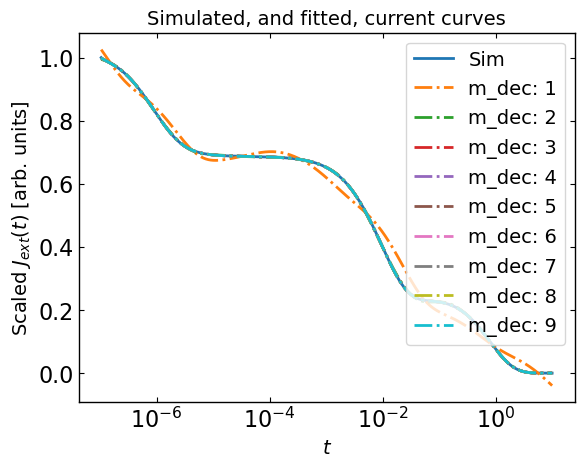

In [6]:
# Plot results
plt.plot(time, current_scaled, label='Sim')

for i in range(len(fits)):
    fit = fits[i]
    plt.plot(time, fit.DRT_curve, linestyle='-.', label=f"m_dec: {m_dec_values[i]}")

plt.xscale('log')
plt.ylabel('Scaled $J_{ext}(t)$ [arb. units]')
plt.xlabel('$t$')
plt.title(f"Simulated, and fitted, current curves")
plt.legend()
plt.show()

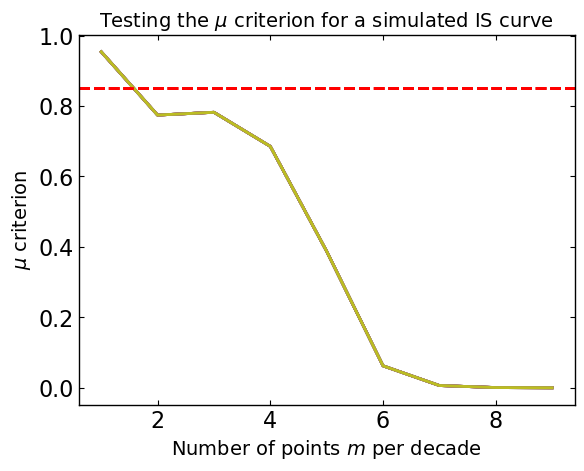

In [7]:
# Plot the mu values for each no points per decade
for i in range(len(fits)):
    plt.plot(m_dec_values, mu_values)
    plt.axhline(0.85, label='$c=0.85$ threshold', linestyle='--', color='red')
    plt.xlabel("Number of points $m$ per decade")
    plt.ylabel("$\\mu$ criterion")
    plt.title("Testing the $\\mu$ criterion for a simulated IS curve")

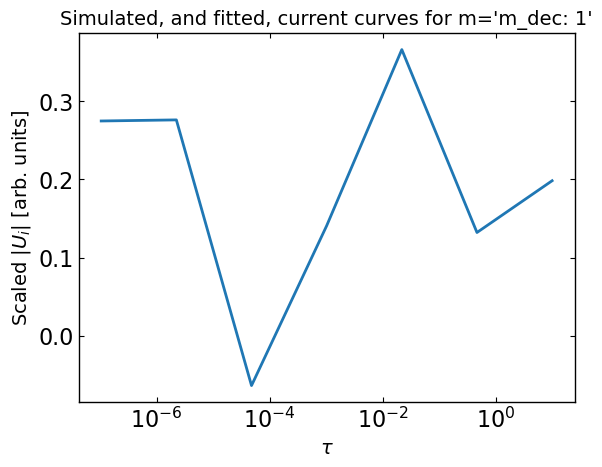

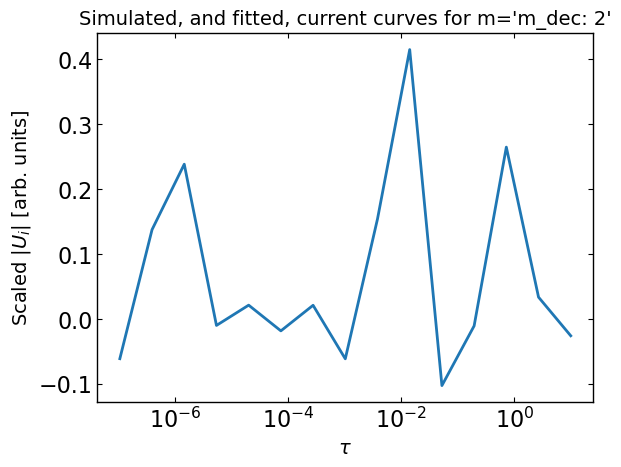

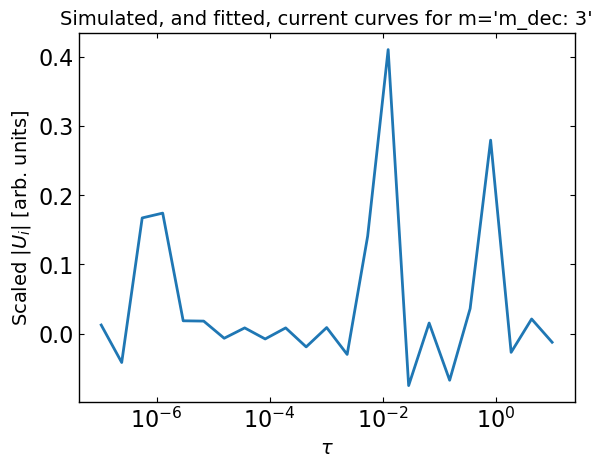

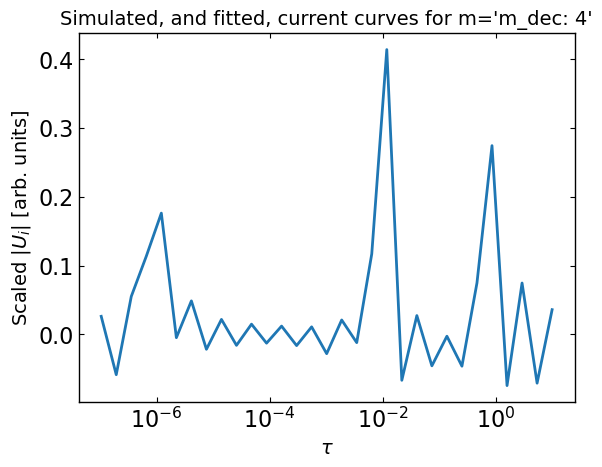

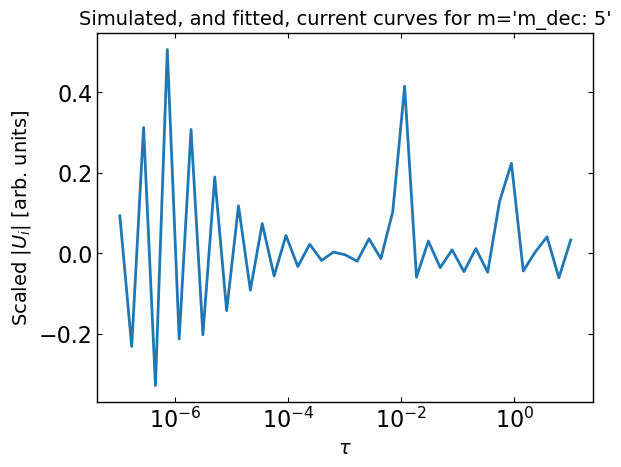

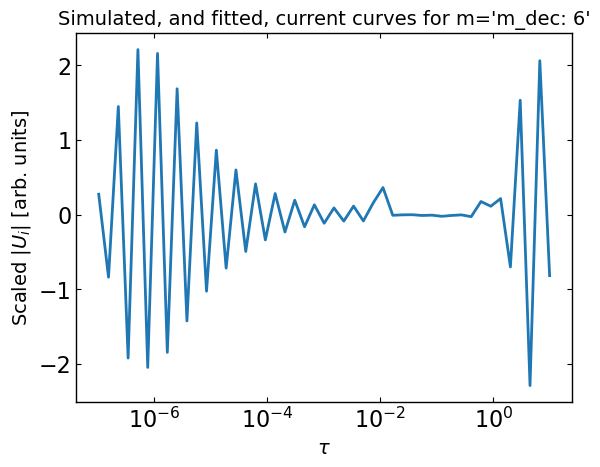

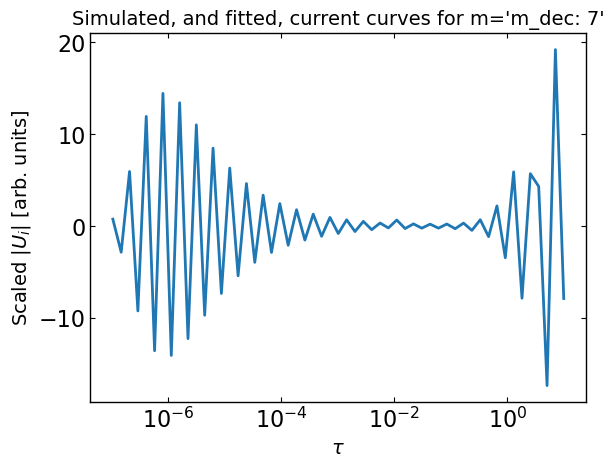

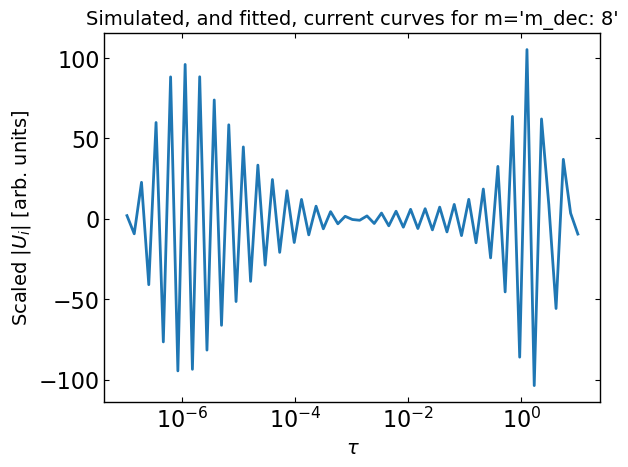

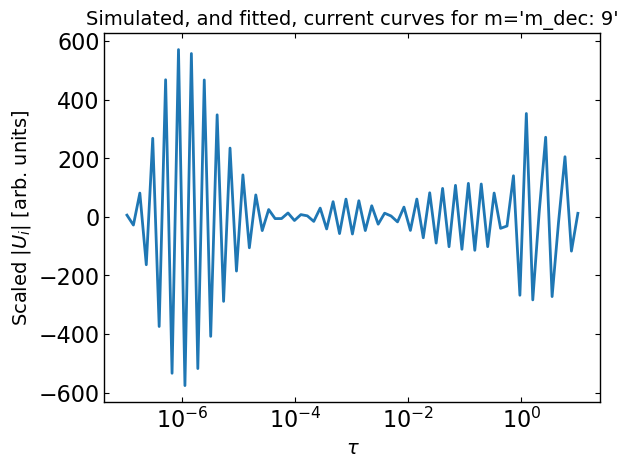

In [8]:
for i in range(len(fits)):
    fit = fits[i]
    tau = np.geomspace(time[0], time[-1], int(m_dec_values[i]*no_decades))
    plt.plot(tau, fit.U)
    plt.xscale('log')
    plt.ylabel('Scaled $|U_i|$ [arb. units]')
    plt.xlabel('$\\tau$')
    plt.title(f"Simulated, and fitted, current curves for m='m_dec: {m_dec_values[i]}'")
    plt.show()

In [9]:
# Find the predicted lifetimes for m_dec=2 
lifetimes_linear = np.geomspace(time[0], time[-1], int(2*no_decades))[np.where(fits[1].U > 0.2)]
lifetimes_linear

array([1.44321565e-06, 1.40808750e-02, 7.21653897e-01])

In [10]:
# Check for the Groningen method of fitting 
m = 3
tau0 = np.geomspace(time[0], time[-1], m)
U0 = np.ones(m)/m
fit_gr = drt.fit_DRT_curve(time, current_scaled, U0, tau0, offset0=current_scaled.min())

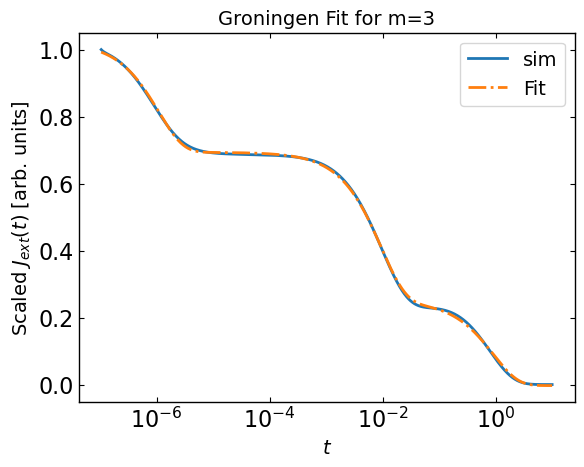

In [11]:
plt.plot(time, current_scaled, label='sim')
plt.plot(time, fit_gr.DRT_curve, linestyle='-.', label='Fit')
plt.xscale('log')
plt.ylabel('Scaled $J_{ext}(t)$ [arb. units]')
plt.xlabel('$t$')
plt.title(f"Groningen Fit for m={m}")
plt.legend()
plt.show()

In [12]:
# Compare lifetimes 
print(f"Lifetimes, Groningen: {fit_gr.tau[0]:.3} {fit_gr.tau[2]:.3} {fit_gr.tau[1]:.3}")
print(f"Lifetimes, linear:    {lifetimes_linear[0]:.3} {lifetimes_linear[2]:.3} {lifetimes_linear[1]:.3}") 

Lifetimes, Groningen: 1.09e-06 0.91 0.00939
Lifetimes, linear:    1.44e-06 0.722 0.0141


## Testing the $\mu$ criterion on an IS with an inductive feature


[]

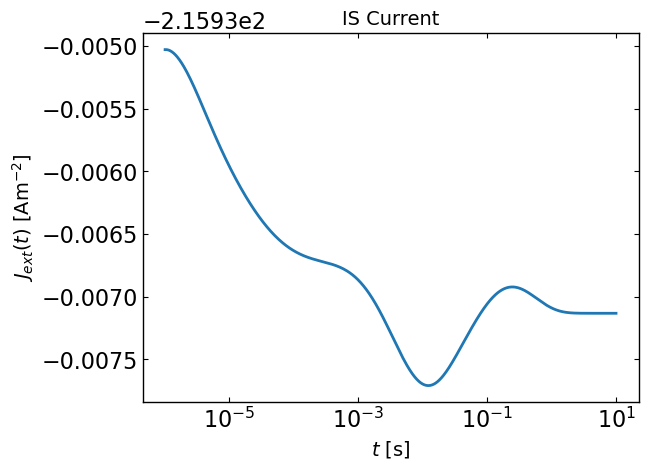

In [13]:
# Reduce the window of current and time to be used for fitting
start_index = 155
end_index = -1

time = data_ind['t'].iloc[start_index:end_index].values
current_density = (data_ind['Jext'].iloc[start_index:end_index].values)
current_density_numerical_error = data_ind['errJ'].iloc[start_index:end_index].values

plt.plot(time, current_density)
plt.xscale('log')
plt.xlabel('$t$ [$\\text{s}$]')
plt.ylabel('$J_{ext}(t)$ [$\\text{A} \\text{m}^{-2}$]')
plt.title("IS Current")
plt.plot()

In [14]:
# Scale current and error 
current_scaled = (current_density - current_density.min())/(current_density.max()-current_density.min())

In [15]:
m_dec_values = range(1,10)
mu_values = []
fits = []
no_decades = np.log10(time[-1]/time[0])
print(no_decades)

# Use linear fit for m_dec = [1, 10], checking [mu] as we go 
for m_dec in m_dec_values:
    # Generate m_dec lifetimes per decade 
    tau = np.geomspace(time[0], time[-1], int(m_dec*no_decades))

    # Fit the curve using linear fit
    fit = drt.fit_DRT_curve_linear(time, current_scaled, tau, U_scale_factor=1, offset=current_scaled.min(), backend='torch')
    fits.append(fit)

    # Sum inductive and capacitive constants
    sum_U_ind = np.absolute(fit.U[np.where(fit.U < 0)]).sum()
    sum_U_cap = np.absolute(fit.U[np.where(fit.U >= 0)]).sum()

    # Calculate mu 
    mu = 1 - sum_U_ind/sum_U_cap
    mu_values.append(mu)

6.986981146352469


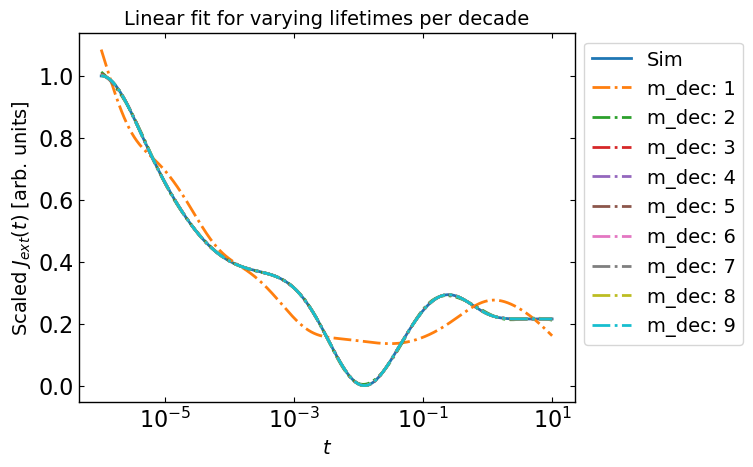

In [16]:
# Plot results
plt.plot(time, current_scaled, label='Sim')

for i in range(len(fits)):
    fit = fits[i]
    plt.plot(time, fit.DRT_curve, linestyle='-.', label=f"m_dec: {m_dec_values[i]}")

plt.xscale('log')
plt.ylabel('Scaled $J_{ext}(t)$ [arb. units]')
plt.xlabel('$t$')
plt.title(f"Linear fit for varying lifetimes per decade")
plt.legend(bbox_to_anchor=(1,1), loc='upper left')
plt.show()

In [17]:
for mu in mu_values:
    print(mu)

0.8836865833544056
0.5352635280246598
0.4329979410444842
0.24605550462095982
0.07725767992970822
0.008684973888851255
0.0033723247036020476
0.00027150406660580995
0.0010254551269079926


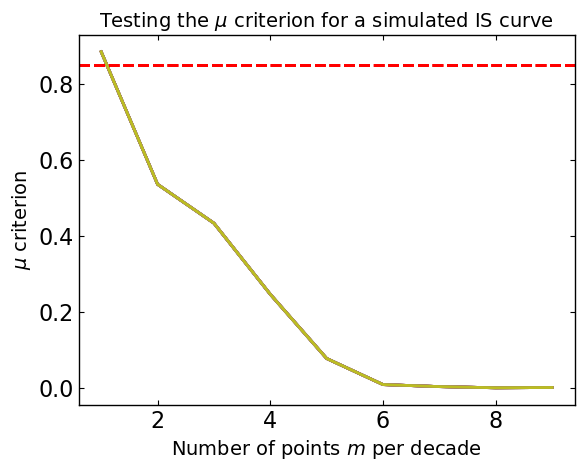

In [18]:
# Plot the mu values for each no points per decade
for i in range(len(fits)):
    plt.plot(m_dec_values, mu_values)
    plt.axhline(0.85, label='$c=0.85$ threshold', linestyle='--', color='red')
    plt.xlabel("Number of points $m$ per decade")
    plt.ylabel("$\\mu$ criterion")
    plt.title("Testing the $\\mu$ criterion for a simulated IS curve")

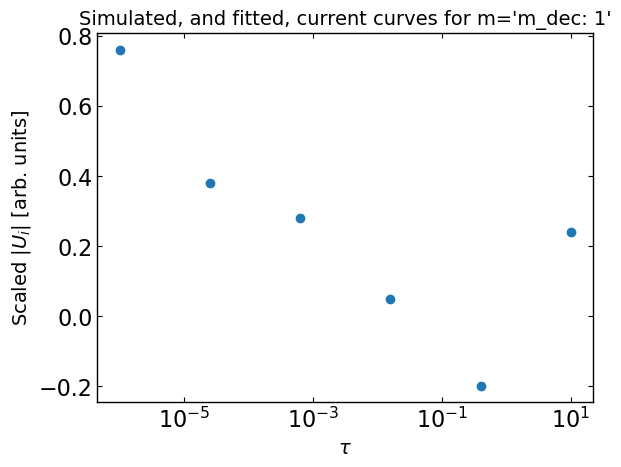

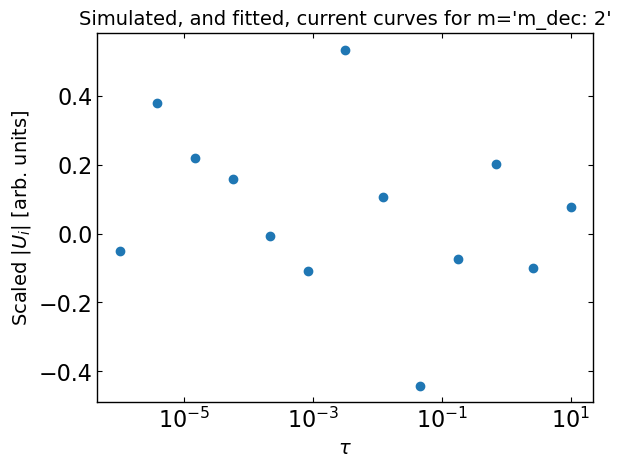

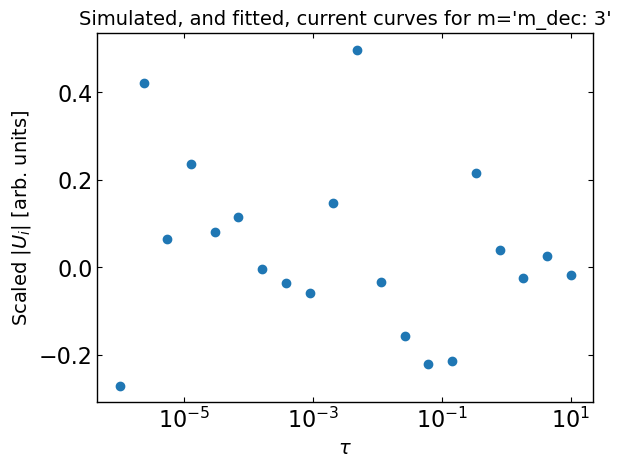

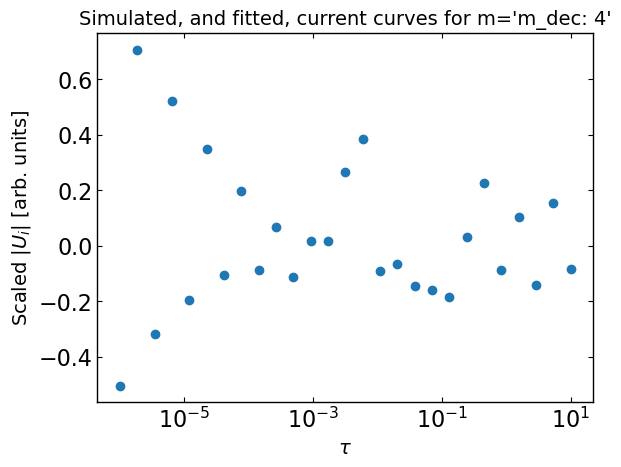

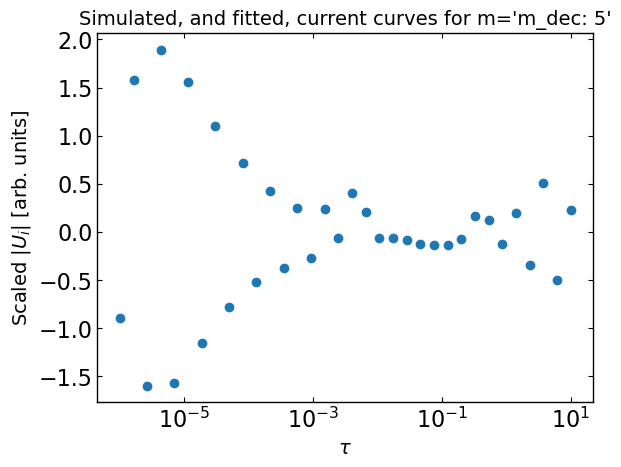

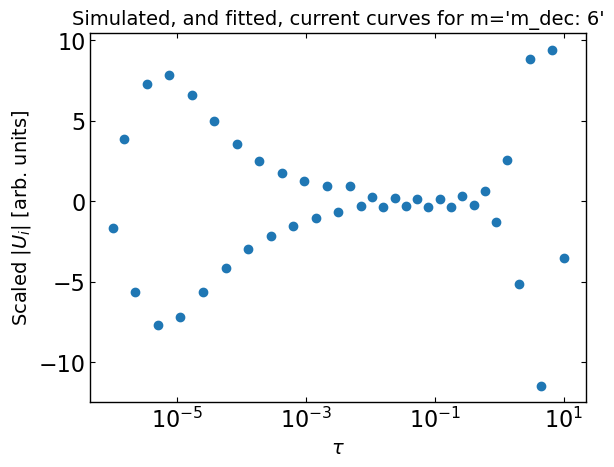

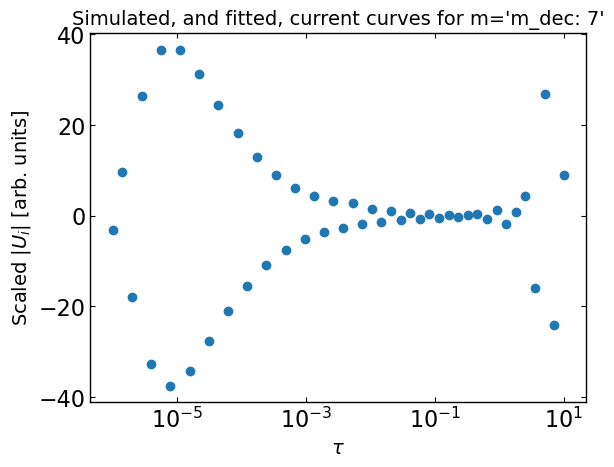

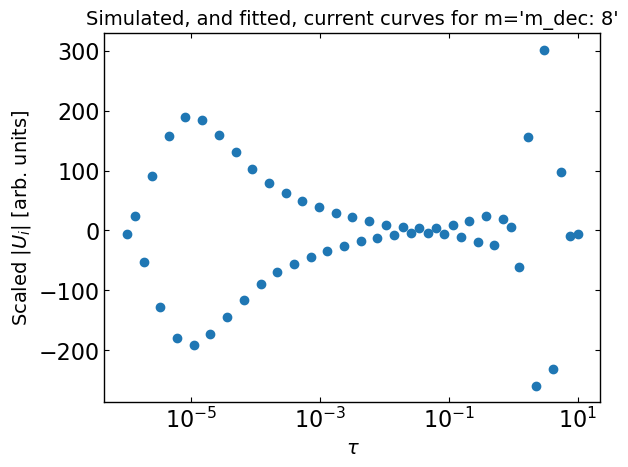

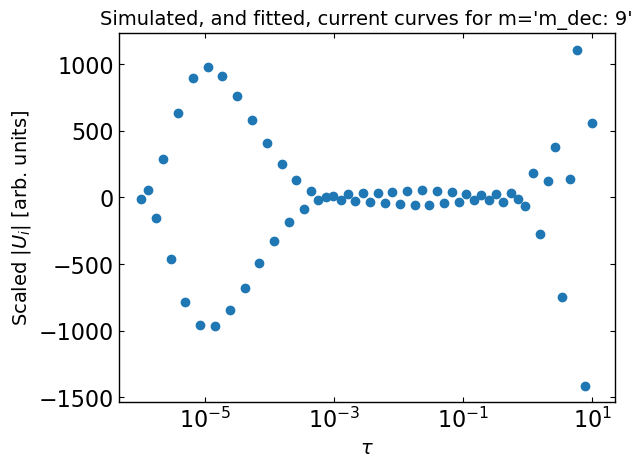

In [19]:
for i in range(len(fits)):
    fit = fits[i]
    tau = np.geomspace(time[0], time[-1], int(m_dec_values[i]*no_decades))
    plt.scatter(tau, fit.U)
    plt.xscale('log')
    plt.ylabel('Scaled $|U_i|$ [arb. units]')
    plt.xlabel('$\\tau$')
    plt.title(f"Simulated, and fitted, current curves for m='m_dec: {m_dec_values[i]}'")
    plt.show()

In [20]:
# Find the predicted lifetimes for m_dec=2 
lifetimes_linear = np.geomspace(time[0], time[-1], int(2*no_decades))[np.where(fits[0].U > 0.2)]
lifetimes_linear

array([1.02600000e-06, 3.92099050e-06, 1.49845677e-05, 8.36352781e-04])

In [21]:
# Compare to the lifetimes picked out by the Groningen method for m=6
m = 6
tau0 = np.geomspace(time[0], time[-1], m)
U0 = np.ones(m)/m
fit_gr = drt.fit_DRT_curve(time, current_scaled, U0, tau0, offset0=current_scaled.min())

/home/josh-edmundson/Documents/SIMsalabim-installs/pySIMsalabim/Notebooks/Projects/Den RT/Mu Test/../../../../pySIMsalabim/aux_funcs/time_domain_DRT.py:148: RuntimeWarning: overflow encountered in exp
  calculated_DRT_curve = (U @ np.exp(-np.outer(1/tau, t))) + offset


In [22]:
# Approximate the error
error_approx = np.sqrt(np.sum((current_scaled - current_scaled.mean())**2)/(len(current_scaled) - 1))

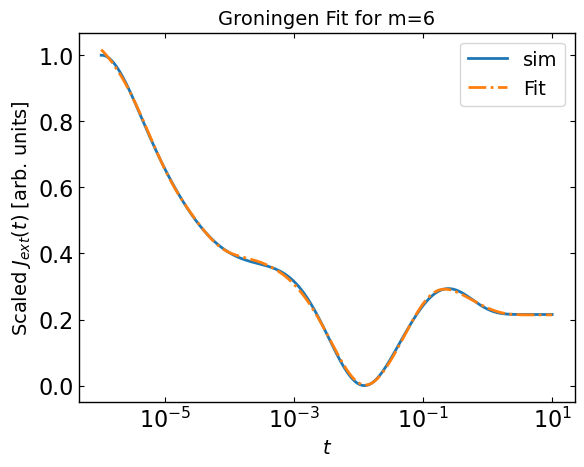

In [23]:
plt.plot(time, current_scaled, label='sim')
plt.plot(time, fit_gr.DRT_curve, linestyle='-.', label='Fit')
plt.xscale('log')
plt.ylabel('Scaled $J_{ext}(t)$ [arb. units]')
plt.xlabel('$t$')
plt.title(f"Groningen Fit for m={m}")
plt.legend()
plt.show()

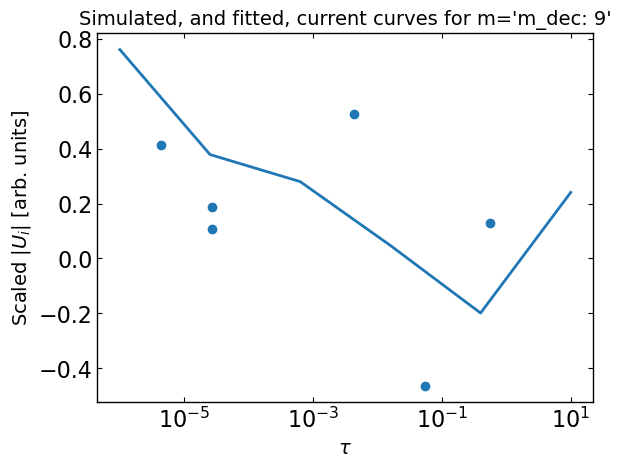

In [24]:

fit = fits[0]
tau = np.geomspace(time[0], time[-1], int(1*no_decades))
plt.plot(tau, fit.U)
plt.scatter(fit_gr.tau, fit_gr.U)
plt.xscale('log')
plt.ylabel('Scaled $|U_i|$ [arb. units]')
plt.xlabel('$\\tau$')
plt.title(f"Simulated, and fitted, current curves for m='m_dec: {m_dec_values[i]}'")
plt.show()

In [25]:
# Assuming Gaussian Probabilites
def P_gaussian(x, mean, std):
    coef = 1/np.sqrt(2*np.pi*std**2)
    exp = np.exp((x - mean)**2/(2*std**2))
    return coef*exp

def calc_likelihood_gr(x, fit_drt):
    sstd = np.sqrt(np.sum((x - x.mean())**2)/(len(x) - 1))
    return np.prod(P_gaussian(current_scaled, fit_drt.DRT_curve, sstd))

def calc_BIC(x, fit_drt):
    return -2*np.log(calc_likelihood_gr(x, fit_drt)) + 2*fit_drt.m*np.log(len(x))

In [26]:
# Use BIC for varying levels of the Groningen fit
offset0 = current_scaled.min()
bic = []

# Set iteration variables
m_values = range(1,11)
fits_gr = []

for m in m_values:
    # Set the initial guesses for parameters that do depend on m
    U0 = np.ones(m)/m
    tau0 = np.geomspace(time[0], time[-1], m)

    # Apply the fit
    fit = drt.fit_DRT_curve(time, current_scaled, U0, tau0, offset0=offset0) 

    # Calculate BIC
    bic.append(calc_BIC(current_scaled, fit))

    # Add to collection of fits
    fits_gr.append(fit)

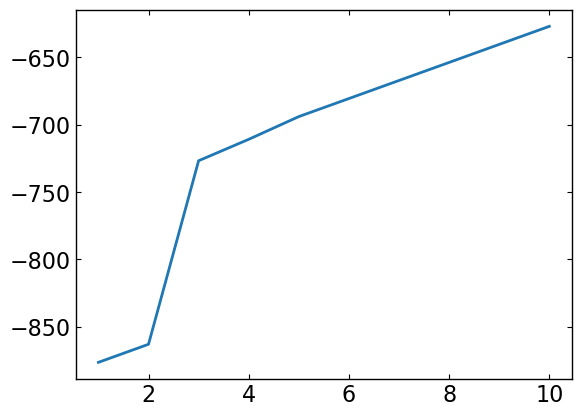

In [27]:
# Plot the BIC score against m 
m_values = [fit.m for fit in fits_gr]

plt.plot(m_values, bic)

In [28]:
10*np.log(len(current_density))

np.float64(66.98268054115414)